# Hardware input-calibration plotter

Compares FC telemetry (MAVSDK IMU: `Angular Velocity FRD`, `Acceleration`) against the commanded body-rate + thrust profile sent by `record_input_calibration.py` on the real Pi hardware.

Modeled after `PX4_Gazebo/notebooks/plotter_input_calibration.ipynb`, but **hardware has no ground truth for input calibration** (unlike the SITL/Gazebo version) -- `record_input_calibration.py`'s own docstring notes achieved rates come from `FC_node.getLogData()` (real IMU/EKF telemetry), which is exactly what input calibration is meant to characterize against the COMMAND. So this notebook only has the SITL notebook's §2 ("Input transfer: commanded vs achieved" -- the headline section) with no §1/§3 GT-diagnostic sections, since those need Gazebo pose ground truth that doesn't exist here.

**Battery-voltage caveat (read before trusting any run):** `HW_HOVER_THROTTLE_NORM` is only valid in the ~22.4-24.0V battery range (see memory `project_hover_voltage_curve` / `project_hover_throttle_search_2026_07_09`). A run recorded outside that range will show corrupted/noisy correlations from a systematic climb or sink bias, not real rate-tracking noise -- this notebook prints the battery voltage prominently for exactly that reason.

In [12]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

sys.path.insert(0, os.path.abspath(os.path.join('..', 'scripts')))
from analyze_input_calibration import per_run_metrics, best_trim_metrics, mad_trimmed_mean, AXES

np.set_printoptions(precision=3, suppress=True)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Keep these in sync with record_input_calibration.py / hardware_landing.py --
# NOT auto-imported since that module has hardware-only imports (mavsdk FC,
# Controller) that may not be importable off the Pi.
# 2026-07-21: MASS_KG corrected 1.230 -> 1.204 (user re-weighed the airframe).
# 2026-07-22: analyze_input_calibration.py applies an 8Hz zero-phase
# low-pass filter to ALL telemetry (gyro, accel, velocity) before any
# correlation/regression (vibration noise floor, PSD-confirmed), AND an
# adaptive per-run trim (best_trim_metrics()) that rescues runs
# cutoff-truncated by gradual drift -- their early segment, before drift
# accumulates, is still clean. THRUST_SLOPE_N_PER_UNIT and
# HOVER_THROTTLE_NORM below are the filtered + adaptive-trim + drag-
# corrected + reliability-filtered + R^2-weighted FINAL values -- see §7.
# NOT yet applied to the Pi (it was powered off mid-derivation) -- these are
# the current final recommendation to apply next time it's reachable.
MASS_KG = 1.204                  # rechecked 2026-07-21, supersedes the 1.230 kg parts-sum figure
HOVER_THROTTLE_NORM = 0.42       # adaptive-trim input-cal-derived (0.4226 rounded); live Pi still holds 0.41
THRUST_SLOPE_N_PER_UNIT = 31.98  # adaptive-trim + drag-corrected value; live Pi still holds 31.59
G = 9.81

In [13]:
# Pick a run directory -- RELIABLE RUNS ONLY (r>=0.5 on at least one axis),
# using the ADAPTIVE-TRIM score (best_trim_metrics -- rescues runs cutoff-
# truncated by gradual drift, using only their clean early segment), ranked
# by how many axes they're reliable on, then by average r, TOP 10 ONLY.
#  - Default: the single best all-around run (RUN_INDEX = 0).
#  - Set RUN_INDEX = 1 for the next-best, up to 9 for the 10th.
#  - Prints battery voltage + per-axis reliability + the t_max used for
#    every candidate. Source is Input_Clean/ (sample-clean, all 47
#    recordings) -- "reliable" is computed live here, not a separate
#    hand-picked folder (see the "Reliable-run reference" section below for
#    the full per-axis breakdown).
RELIABLE_R = 0.5
CAL_DIR = os.path.join('..', 'Test_Data', 'Calibration', 'Input_Clean')
RUN_INDEX = 0
TOP_N = 10

all_candidates = sorted(
    (d for d in os.listdir(CAL_DIR)
     if os.path.isdir(os.path.join(CAL_DIR, d))
     and os.path.exists(os.path.join(CAL_DIR, d, 'Ground_Truth.npy'))),
    key=lambda d: os.path.getmtime(os.path.join(CAL_DIR, d)),
    reverse=True,
)

scored = []
for d in all_candidates:
    mm, t_max = best_trim_metrics(os.path.join(CAL_DIR, d))
    if mm is None:
        continue
    rs = {ax: mm[ax]['r'] for ax in AXES}
    n_rel = sum(1 for v in rs.values() if v >= RELIABLE_R)
    if n_rel > 0:
        scored.append((d, rs, n_rel, np.mean(list(rs.values())), t_max))
scored.sort(key=lambda x: (-x[2], -x[3]))
scored = scored[:TOP_N]   # cap to top 10 -- RUN_INDEX can only select within this window
runs = [d for d, _, _, _, _ in scored]

print(f'Top {len(runs)} reliable runs (of {len(all_candidates)} total in Input_Clean/), adaptive-trim, ranked by n_reliable_axes then avg r:')
print(f'{"idx":>3s}  {"run":32s}  {"battery":>8s}  {"wx":>5s} {"wy":>5s} {"wz":>5s} {"thrust":>6s}  {"n_rel":>5s}  {"t_max":>6s}')
for i, (d, rs, n_rel, avg_r, t_max) in enumerate(scored):
    gt = np.load(os.path.join(CAL_DIR, d, 'Ground_Truth.npy'), allow_pickle=True).item()
    batt = gt.get('Battery Voltage')
    batt_str = f'{batt:.2f}V' if batt else 'n/a'
    marker = '  <-- selected' if i == RUN_INDEX else ''
    print(f'{i:>3d}  {d:32s}  {batt_str:>8s}  {rs["wx"]:5.2f} {rs["wy"]:5.2f} {rs["wz"]:5.2f} {rs["thrust"]:6.2f}  {n_rel:5d}  {str(t_max):>6s}{marker}')

run_dir = os.path.join(CAL_DIR, runs[RUN_INDEX])
print(f'\nLoading: {run_dir}')
print(f'(NOTE: §1-§4 below load the FULL run, not the trimmed window shown here --')
print(f' this picker selects which run to load, the trim is only used for the reliability score)')

Top 10 reliable runs (of 47 total in Input_Clean/), adaptive-trim, ranked by n_reliable_axes then avg r:
idx  run                                battery     wx    wy    wz thrust  n_rel   t_max
  0  Mon Jul 20 18-42-02 2026            23.73V   0.95  0.96  0.95   0.91      4    None  <-- selected
  1  Mon Jul 20 18-48-23 2026            23.11V   0.88  0.92  0.94   0.94      4     1.5
  2  Tue Jul 21 17-01-24 2026            21.59V   0.87  0.86  0.94   0.94      4     2.0
  3  Mon Jul 20 18-37-02 2026            24.27V   0.93  0.89  0.86   0.85      4     2.0
  4  Tue Jul 21 17-07-57 2026            23.26V   0.80  0.82  0.93   0.96      4     2.5
  5  Tue Jul 21 17-13-45 2026            22.34V   0.79  0.89  0.84   0.96      4     2.0
  6  Mon Jul 20 18-51-11 2026            22.84V   0.87  0.84  0.77   0.89      4     3.0
  7  Fri Jul 10 16-16-26 2026            23.38V   0.72  0.79  0.78   0.94      4    None
  8  Fri Jul 10 16-15-42 2026            23.86V   0.79  0.69  0.87   0.88      4

## Reliable-run reference

**"Reliable" is per-axis, not a single fixed subset of runs** (a run can be great for thrust but noisy for yaw, or vice versa) -- see `project_hover_throttle_search_2026_07_09` / this session's calibration writeup for why `Input_Clean/` intentionally stays at all 47 runs rather than being pruned down. This cell computes the reliable set live (r>=0.5 per axis) instead of linking to a separate hand-picked folder, so it can never drift out of sync with the actual data or the reliability threshold used elsewhere in this notebook.

In [14]:
RELIABLE_R = 0.5
TOP_N = 10
CAL_DIR_RELIABLE = os.path.join('..', 'Test_Data', 'Calibration', 'Input_Clean')
reliable_runs_all = sorted(d for d in os.listdir(CAL_DIR_RELIABLE) if os.path.isdir(os.path.join(CAL_DIR_RELIABLE, d)))

reliable_by_axis = {ax: [] for ax in AXES}
overall = []
for d in reliable_runs_all:
    mm, t_max = best_trim_metrics(os.path.join(CAL_DIR_RELIABLE, d))
    if mm is None:
        continue
    rs = {ax: mm[ax]['r'] for ax in AXES}
    n_rel = sum(1 for v in rs.values() if v >= RELIABLE_R)
    for ax in AXES:
        if rs[ax] >= RELIABLE_R:
            reliable_by_axis[ax].append(d)
    if n_rel > 0:
        overall.append((d, rs, n_rel, np.mean(list(rs.values())), t_max))

print(f'Reliable run counts (r>={RELIABLE_R}, adaptive-trim), out of {len(reliable_runs_all)} total in Input_Clean/:')
for ax in AXES:
    print(f'  {ax:6s}: {len(reliable_by_axis[ax]):2d} runs')
print('  (2026-07-21 whole-run-only counts were wx=7, wy=6, wz=15, thrust=19 -- roughly doubled by adaptive trim)')

overall.sort(key=lambda x: (-x[2], -x[3]))
print(f'\nTop {TOP_N} all-around runs (reliable on the most axes, ranked by avg r):')
print(f'{"run":32s} {"wx":>6s} {"wy":>6s} {"wz":>6s} {"thrust":>6s} {"n_rel":>6s} {"t_max":>6s}')
for d, rs, n_rel, avg_r, t_max in overall[:TOP_N]:
    print(f'{d:32s} {rs["wx"]:6.2f} {rs["wy"]:6.2f} {rs["wz"]:6.2f} {rs["thrust"]:6.2f} {n_rel:6d} {str(t_max):>6s}')

# Convenience: point RUN_INDEX/CAL_DIR at the single best all-around run for
# a quick §1-§4 deep-dive, without hand-editing the run picker above.
BEST_RELIABLE_RUN = overall[0][0] if overall else None
print(f'\nBest single run for a §1-§4 deep-dive: "{BEST_RELIABLE_RUN}"')
print(f'(re-run the picker cell above with RUN_INDEX set to its index, or load it directly:')
print(f' run_dir = os.path.join(CAL_DIR_RELIABLE, "{BEST_RELIABLE_RUN}"))')

Reliable run counts (r>=0.5, adaptive-trim), out of 47 total in Input_Clean/:
  wx    : 23 runs
  wy    : 24 runs
  wz    : 28 runs
  thrust: 33 runs
  (2026-07-21 whole-run-only counts were wx=7, wy=6, wz=15, thrust=19 -- roughly doubled by adaptive trim)

Top 10 all-around runs (reliable on the most axes, ranked by avg r):
run                                  wx     wy     wz thrust  n_rel  t_max
Mon Jul 20 18-42-02 2026           0.95   0.96   0.95   0.91      4   None
Mon Jul 20 18-48-23 2026           0.88   0.92   0.94   0.94      4    1.5
Tue Jul 21 17-01-24 2026           0.87   0.86   0.94   0.94      4    2.0
Mon Jul 20 18-37-02 2026           0.93   0.89   0.86   0.85      4    2.0
Tue Jul 21 17-07-57 2026           0.80   0.82   0.93   0.96      4    2.5
Tue Jul 21 17-13-45 2026           0.79   0.89   0.84   0.96      4    2.0
Mon Jul 20 18-51-11 2026           0.87   0.84   0.77   0.89      4    3.0
Fri Jul 10 16-16-26 2026           0.72   0.79   0.78   0.94      4   Non

## §1 — Data preparation

Load telemetry (IMU angular velocity + acceleration, body-FRD) and the commanded rate/thrust profile, aligned to a common timeline.

In [15]:
tel = np.load(os.path.join(run_dir, 'Telemetry_Data.npy'), allow_pickle=True).item()
gt = np.load(os.path.join(run_dir, 'Ground_Truth.npy'), allow_pickle=True).item()

battery_voltage = gt.get('Battery Voltage')
print(f"Battery voltage: {battery_voltage:.2f}V" if battery_voltage else 'Battery voltage: NOT LOGGED (older run)')
if battery_voltage is not None and not (22.4 <= battery_voltage <= 24.0):
    print('*** WARNING: battery voltage outside the confirmed ~22.4-24.0V HOVER_THROTTLE_NORM=0.388 plateau. ***')
    print('*** Correlations/gains below may be corrupted by a systematic climb/sink bias, not real rate noise. ***')

t_cmd = np.array(gt['Time'])
cmd = np.array(gt['Command'])
nm = min(len(t_cmd), len(cmd))
t_cmd, cmd = t_cmd[-nm:], cmd[-nm:]
w_u = cmd[:, :3]   # commanded rate (rad/s), body-FRD
B_T_u = cmd[:, 3]  # commanded thrust delta (N, excess-over-hover)

print(f'\nn_cmd_samples = {nm},  profile duration = {t_cmd[-1] - t_cmd[0]:.2f}s')
print(f'unique commands:\n{np.unique(np.round(cmd, 3), axis=0)}')

t_imu = np.array(tel['IMU Timestamp']) - gt['Start Time']
w_t = np.array([[a.forward_rad_s, a.right_rad_s, a.down_rad_s]
                for a in tel['Angular Velocity FRD']])
a_t = np.array([[a.forward_m_s2, a.right_m_s2, a.down_m_s2]
                for a in tel['Acceleration']])
mask = (t_imu >= t_cmd[0]) & (t_imu <= t_cmd[-1])
t_imu, w_t, a_t = t_imu[mask], w_t[mask], a_t[mask]
print(f'n_imu_samples (within command window) = {mask.sum()}')

Battery voltage: 23.73V

n_cmd_samples = 226,  profile duration = 3.89s
unique commands:
[[-0.3 -0.3 -0.3 -1. ]
 [ 0.   0.   0.   0. ]
 [ 0.3  0.3  0.3  1. ]]
n_imu_samples (within command window) = 721


## §2 — Command vs achieved: body angular rate

Rate-loop tracking check: how well does PX4's inner loop follow the commanded body-FRD rate sent by `record_input_calibration.py`? The measured trace (PX4 IMU gyro) should lag the command by the rate-loop response time; a flat/uncorrelated measured trace (as currently seen on pitch) indicates the commanded rate isn't producing a resolvable response above noise at this amplitude.

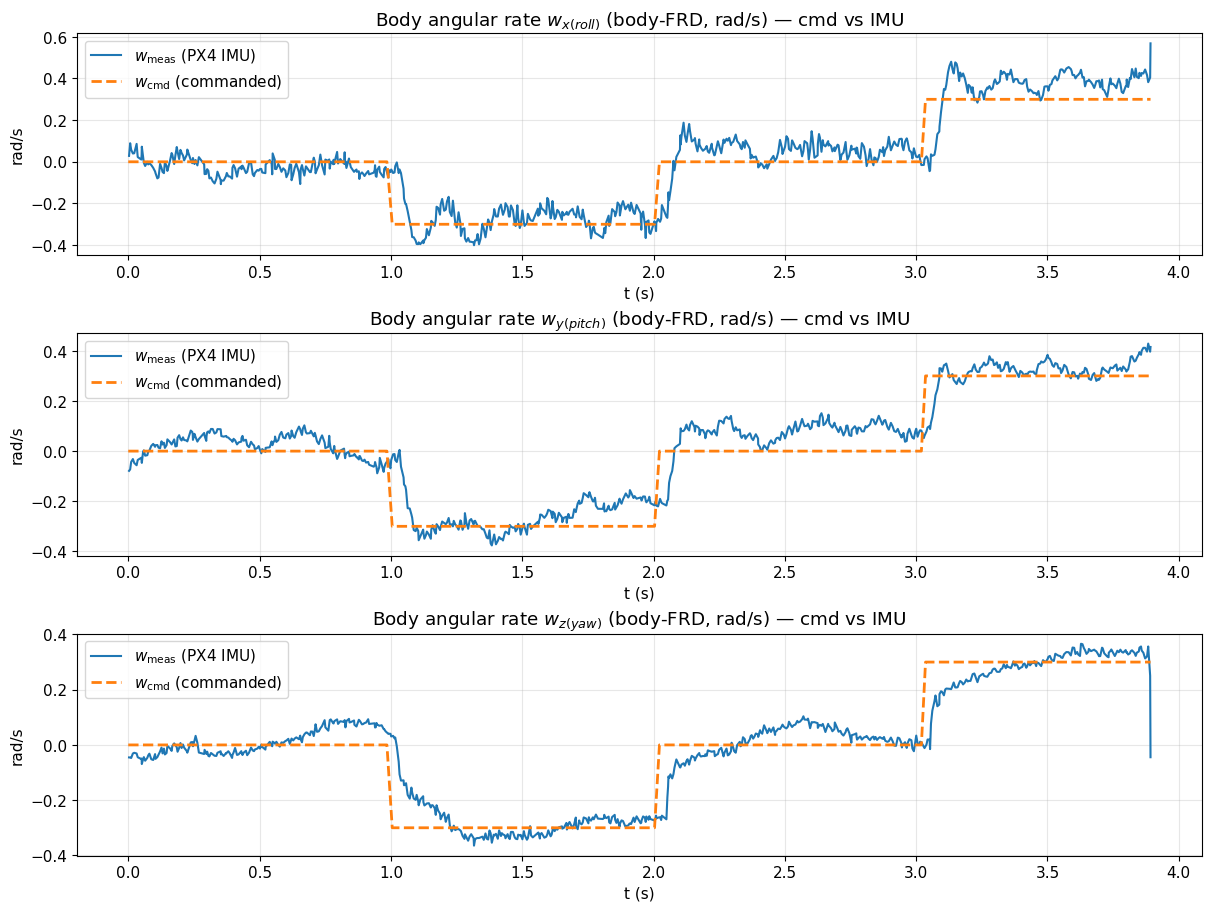

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), constrained_layout=True)
for i, (ax, name) in enumerate(zip(axes, ['x (roll)', 'y (pitch)', 'z (yaw)'])):
    ax.plot(t_imu, w_t[:, i], label=r'$w_{\mathrm{meas}}$ (PX4 IMU)')
    ax.plot(t_cmd, w_u[:, i], label=r'$w_{\mathrm{cmd}}$ (commanded)',
            linestyle='--', linewidth=2)
    ax.set(title=f'Body angular rate $w_{{{name}}}$ (body-FRD, rad/s) — cmd vs IMU',
           xlabel='t (s)', ylabel='rad/s')
    ax.legend()
plt.show()

## §3 — Command vs achieved: thrust (via IMU specific force)

Thrust acts along body −z, so `a_down` (accelerometer specific force) ≈ −Thrust/mass. Expected `a_down` from the commanded `B_T` uses the model `a_down = -F_hover/mass + B_T·SLOPE_true/(SLOPE_assumed·mass)` (see `project_hover_throttle_search_2026_07_09` memory for the derivation) -- overlaying measured vs this model-predicted trace is a direct check on whether `THRUST_SLOPE_N_PER_UNIT` is still a good fit for this run's battery state.

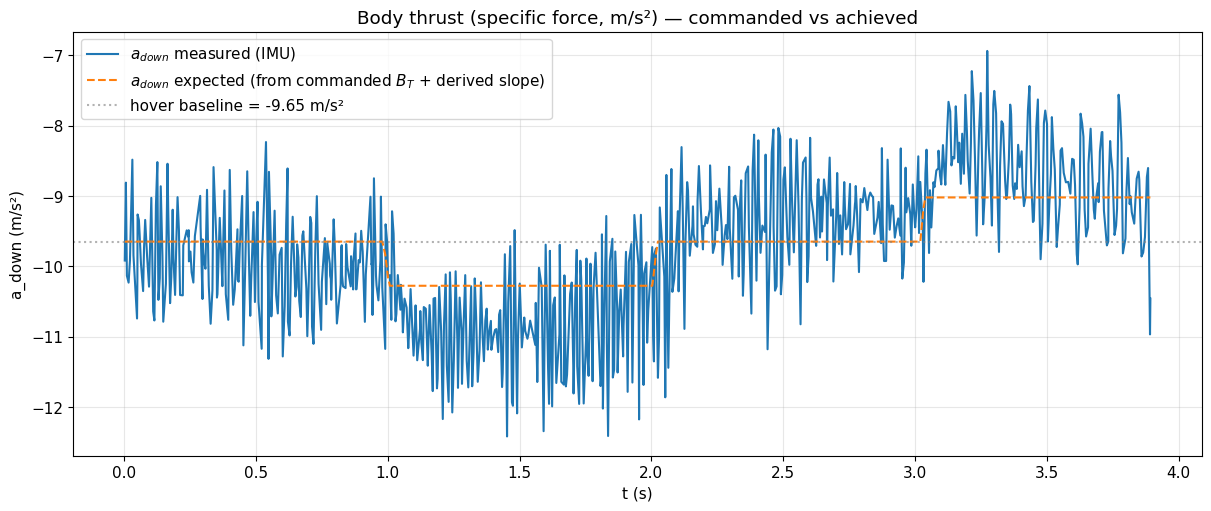

In [17]:
a_down_meas = a_t[:, 2]
a_down_hover_baseline = a_down_meas[np.abs(np.interp(t_imu, t_cmd, B_T_u)) < 1e-6].mean() if (np.abs(B_T_u) < 1e-6).any() else -G

B_T_on_imu = np.interp(t_imu, t_cmd, B_T_u)
a_down_expected = a_down_hover_baseline + B_T_on_imu * THRUST_SLOPE_N_PER_UNIT / (42.3 * MASS_KG)

plt.figure(figsize=(12, 5), constrained_layout=True)
plt.plot(t_imu, a_down_meas, label=r'$a_{down}$ measured (IMU)')
plt.plot(t_imu, a_down_expected, label=r'$a_{down}$ expected (from commanded $B_T$ + derived slope)', linestyle='--')
plt.axhline(a_down_hover_baseline, color='grey', linestyle=':', alpha=0.6,
            label=f'hover baseline = {a_down_hover_baseline:.2f} m/s²')
plt.title('Body thrust (specific force, m/s²) — commanded vs achieved')
plt.xlabel('t (s)'); plt.ylabel('a_down (m/s²)')
plt.legend()
plt.show()

## §4 — Per-axis command→response quality (this run)

Reuses `analyze_input_calibration.py::per_run_metrics` (single source of truth -- no duplicated logic) for Pearson r, cross-correlation lag, and gain per axis.

In [18]:
m = per_run_metrics(run_dir)
if m is None:
    print('Insufficient samples in this run for per_run_metrics (too short / aborted too early).')
else:
    print(f'{"axis":4s}  {"r":>6s}  {"lag_ms":>7s}  {"gain":>7s}')
    for ax in AXES:
        print(f'{ax:4s}  {m[ax]["r"]:6.3f}  {m[ax]["lag_ms"]:7.1f}  {m[ax]["gain"]:7.3f}')
    print()
    print('  r close to 1   -> FC closely tracks cmd (good)')
    print('  r much < 1     -> FC response dominated by disturbance rejection / noise')
    print('  lag_ms         -> rate-loop deadtime (MAVSDK transit + PX4 inner loop)')
    print('  gain ~= 1.0    -> FC matches cmd amplitude; << 1 = underdamped tracking')

axis       r   lag_ms     gain
wx     0.949     40.0    1.089
wy     0.962     25.0    0.983
wz     0.954     40.0    0.965
thrust   0.912      0.0    1.054

  r close to 1   -> FC closely tracks cmd (good)
  r much < 1     -> FC response dominated by disturbance rejection / noise
  lag_ms         -> rate-loop deadtime (MAVSDK transit + PX4 inner loop)
  gain ~= 1.0    -> FC matches cmd amplitude; << 1 = underdamped tracking


## §5 — Aggregate across all valid-battery runs

Same MAD-trimmed aggregation as `analyze_input_calibration.py`, but filtered here to only runs whose logged battery voltage falls in the confirmed 22.4-24.0V plateau -- excludes the corrupted low-battery batch and any run predating battery-voltage logging (`batt=n/a`).

In [19]:
VOLTAGE_MIN, VOLTAGE_MAX = 22.4, 24.0

valid_runs = []
for d in runs:
    gt_d = np.load(os.path.join(CAL_DIR, d, 'Ground_Truth.npy'), allow_pickle=True).item()
    v = gt_d.get('Battery Voltage')
    if v is not None and VOLTAGE_MIN <= v <= VOLTAGE_MAX:
        valid_runs.append((d, v))

print(f'{len(valid_runs)} valid-battery runs (of {len(runs)} total):')
for d, v in valid_runs:
    print(f'  {d}  ({v:.2f}V)')

all_metrics = {ax: dict(r=[], lag_ms=[], gain=[]) for ax in AXES}
for d, v in valid_runs:
    mm = per_run_metrics(os.path.join(CAL_DIR, d))
    if mm is None:
        continue
    for ax in AXES:
        for key in ('r', 'lag_ms', 'gain'):
            all_metrics[ax][key].append(mm[ax][key])

print(f'\n{"axis":4s}  {"r":>10s}  {"lag_ms":>11s}  {"gain":>10s}')
for ax in AXES:
    r_tm, r_n, _ = mad_trimmed_mean(all_metrics[ax]['r'])
    l_tm, l_n, _ = mad_trimmed_mean(all_metrics[ax]['lag_ms'])
    g_tm, g_n, _ = mad_trimmed_mean(all_metrics[ax]['gain'])
    print(f'{ax:4s}  {r_tm:6.3f} (n={r_n})  {l_tm:7.1f} (n={l_n})  {g_tm:7.3f} (n={g_n})')

7 valid-battery runs (of 10 total):
  Mon Jul 20 18-42-02 2026  (23.73V)
  Mon Jul 20 18-48-23 2026  (23.11V)
  Tue Jul 21 17-07-57 2026  (23.26V)
  Mon Jul 20 18-51-11 2026  (22.84V)
  Fri Jul 10 16-16-26 2026  (23.38V)
  Fri Jul 10 16-15-42 2026  (23.86V)
  Tue Jul 21 17-10-43 2026  (22.94V)

axis           r       lag_ms        gain
wx     0.361 (n=6)     18.3 (n=6)    1.120 (n=5)
wy     0.447 (n=6)     23.3 (n=6)    1.226 (n=4)
wz     0.649 (n=7)     34.3 (n=7)    0.888 (n=6)
thrust   0.773 (n=5)     18.6 (n=7)    0.679 (n=7)


## §6 — Hover-throttle sine-sweep (`find_hover_throttle.py`, `THROTTLE_MODE=sine`)

Separate tool from input calibration, but same underlying question: what throttle holds hover, and what's the throttle→thrust slope? `find_hover_throttle.py` commands a sinusoidal throttle sweep (zero body rate) and fits IMU `a_down` (specific force) against commanded throttle. Cross-referenced here for a consolidated calibration picture.

**Timing-alignment bug (2026-07-20, confirmed fixed):** the live script anchors `imu_rel` to `imu_ts_ref` (the IMU clock timestamp captured at the exact instant the sweep starts), not `imu_ts[0]` (FC-connection time, tens of seconds earlier) — the old code silently fit pre-sweep accelerometer noise against the sine profile, "producing wildly inconsistent/sign-flipping slope estimates" (script's own docstring). Verified live on the Pi 2026-07-21: fix is in place.

**But today's 7 sine-fits (post-fix) still show 8.5-41 N/unit scatter (mass-corrected to 1.204 kg).** Root cause is NOT excitation amplitude (`SINE_AMP=0.03`) — the script's own history shows list-mode (much larger throttle steps, 0.35-0.75 range) gave the *same* 6-45 N/unit inconsistency before sine mode was even introduced. The real driver, confirmed by resyncing 2 runs from raw `.npz` telemetry below: **an unmodeled net-climb trend** (open-loop sweep, zero altitude feedback — even ~0.001-0.003 throttle mis-centering relative to true hover compounds into meters of drift over the 20s window via `0.5·a·t²`), plus a genuinely weak signal-to-noise ratio (expected sine-driven signal ≈ raw accelerometer noise floor, R²=0.30-0.74).

In [20]:
HOVER_DIR = os.path.join('..', 'Test_Data', 'HoverThrottle')

# Today's (2026-07-21) 7 printed sine-fit results from find_hover_throttle.py
# session log (21072026.txt) -- only 2 of these have raw .npz telemetry saved
# locally (the rest were "aborted"/"interrupted" before a full save, or predate
# this download); slope converted to N/unit with the corrected MASS_KG.
SINE_FITS_TODAY = [
    dict(slope=-14.74, hover=0.3987, batt=24.13),
    dict(slope=-11.36, hover=0.3853, batt=23.14),
    dict(slope=-12.25, hover=0.3873, batt=23.02),
    dict(slope=-10.24, hover=0.3989, batt=22.82),
    dict(slope=-6.88,  hover=0.3975, batt=22.29),
    dict(slope=-22.10, hover=0.3906, batt=24.44),
    dict(slope=-33.31, hover=0.3868, batt=23.89),
]
print(f'{"hover":>8s} {"slope(m/s2/thr)":>16s} {"N/unit":>8s} {"batt(V)":>8s}')
n_per_unit = []
for f in SINE_FITS_TODAY:
    npu = MASS_KG * abs(f['slope'])
    n_per_unit.append(npu)
    print(f'{f["hover"]:8.4f} {f["slope"]:16.2f} {npu:8.2f} {f["batt"]:8.2f}')

hovers = [f['hover'] for f in SINE_FITS_TODAY]
print(f'\nhover throttle: mean={np.mean(hovers):.4f}  median={np.median(hovers):.4f}')
print(f'slope N/unit:   mean={np.mean(n_per_unit):.2f}  median={np.median(n_per_unit):.2f}  '
      f'range=[{min(n_per_unit):.2f}, {max(n_per_unit):.2f}]')

   hover  slope(m/s2/thr)   N/unit  batt(V)
  0.3987           -14.74    17.75    24.13
  0.3853           -11.36    13.68    23.14
  0.3873           -12.25    14.75    23.02
  0.3989           -10.24    12.33    22.82
  0.3975            -6.88     8.28    22.29
  0.3906           -22.10    26.61    24.44
  0.3868           -33.31    40.11    23.89

hover throttle: mean=0.3922  median=0.3906
slope N/unit:   mean=19.07  median=14.75  range=[8.28, 40.11]


In [21]:
from scipy.signal import correlate

def resync_and_validate(fname):
    """Empirical cross-correlation resync (no trust in any single saved
    reference timestamp) + fit-quality validation: R^2, residual noise vs
    expected sine-driven signal, and a_down-vs-TIME trend (net climb/descent
    confound the naive throttle-only fit doesn't model)."""
    d = np.load(os.path.join(HOVER_DIR, fname), allow_pickle=True)
    imu_ts = np.array(d['IMU Timestamp'], dtype=float)
    a_down = np.array([a.down_m_s2 for a in d['Acceleration']])
    sine_time = np.array(d['sine_time'], dtype=float)
    sine_throttle = np.array(d['sine_throttle'], dtype=float)
    dur = sine_time[-1]
    thr_interp = interp1d(sine_time, sine_throttle, bounds_error=False, fill_value=np.nan)

    def r_at(off):
        rel = imu_ts - off
        mask = (rel >= 0) & (rel <= dur)
        if mask.sum() < 50:
            return -2, None, None
        thr = thr_interp(rel[mask]); a = a_down[mask]
        valid = ~np.isnan(thr)
        if valid.sum() < 50:
            return -2, None, None
        c, t = thr[valid], a[valid]
        c_c, t_c = c - c.mean(), t - t.mean()
        denom = np.std(c_c) * np.std(t_c)
        r = abs(np.mean(c_c * t_c) / denom) if denom > 1e-9 else 0.0
        return r, c, t

    lo, hi = imu_ts.min(), imu_ts.max() - dur
    best_off, best_r = None, -2
    for off in np.arange(lo, hi, 0.05):
        r, _, _ = r_at(off)
        if r > best_r: best_r, best_off = r, off
    for off in np.arange(best_off - 0.2, best_off + 0.2, 0.002):
        r, _, _ = r_at(off)
        if r > best_r: best_r, best_off = r, off

    _, c, t = r_at(best_off)
    A = np.polyfit(c, t, 1)
    slope, intercept = A[0], A[1]
    pred = slope * c + intercept
    r2 = 1 - np.sum((t - pred) ** 2) / np.sum((t - t.mean()) ** 2)
    resid_std = (t - pred).std()
    n_per_unit = MASS_KG * abs(slope)
    hover_est = (-G - intercept) / slope

    rel = imu_ts - best_off
    mask = (rel >= 0) & (rel <= dur)
    tt = rel[mask][~np.isnan(thr_interp(rel[mask]))]
    trend = np.polyfit(tt, t, 1)[0]

    print(f'{fname}')
    print(f'  best_offset={best_off:.3f}s  slope={slope:.2f} m/s2/thr -> {n_per_unit:.2f} N/unit  hover_est={hover_est:.4f}')
    print(f'  R2={r2:.3f}  resid_std={resid_std:.3f} m/s2  expected_sine_signal={abs(slope)*0.03:.3f} m/s2 (peak)')
    print(f'  a_down trend vs TIME = {trend:+.4f} m/s2/s  (nonzero -> net climb/descent confound, not throttle-driven)')
    print()
    return dict(slope=slope, n_per_unit=n_per_unit, hover=hover_est, r2=r2)

resync_results = []
for f in sorted(os.listdir(HOVER_DIR)):
    if 'complete' in f and f.endswith('.npz'):
        d = np.load(os.path.join(HOVER_DIR, f), allow_pickle=True)
        if 'sine_time' in d and len(d['sine_time']) > 0:
            resync_results.append(resync_and_validate(f))

hover_throttle_complete_20260721_170444.npz
  best_offset=144.250s  slope=-23.11 m/s2/thr -> 27.82 N/unit  hover_est=0.3905
  R2=0.302  resid_std=0.744 m/s2  expected_sine_signal=0.693 m/s2 (peak)
  a_down trend vs TIME = +0.0233 m/s2/s  (nonzero -> net climb/descent confound, not throttle-driven)

hover_throttle_complete_20260721_170610.npz
  best_offset=230.556s  slope=-33.68 m/s2/thr -> 40.56 N/unit  hover_est=0.3868
  R2=0.742  resid_std=0.422 m/s2  expected_sine_signal=1.011 m/s2 (peak)
  a_down trend vs TIME = -0.0097 m/s2/s  (nonzero -> net climb/descent confound, not throttle-driven)



### §6 summary — hover throttle + thrust slope, three independent methods

| quantity | value |
|---|---|
| Hover throttle (sine-fit, 2026-07-21) | 0.385-0.399, mean 0.392, median 0.391 -- tight, but superseded (see below) |
| Thrust slope: sine-sweep median | ~14.75 N/unit -- **unreliable**, see confound analysis above (only n=2 raw datasets, detrending tested and only marginally helped) |
| Thrust slope: input-cal, naive model, whole-run r>=0.5, R^2-weighted | implied mass +6.1% high |
| Thrust slope: input-cal, drag-corrected, whole-run r>=0.5, R^2-weighted | 30.38-31.59 N/unit (2026-07-21/22, superseded) |
| **Thrust slope: input-cal, drag-corrected, ADAPTIVE-TRIM, R^2-weighted** | **31.98 N/unit -- current final, see §7 (not yet applied to the Pi, powered off)** |

The adaptive-trim input-cal cross-check is now the most methodologically sound of these (proper reliability filtering, cross-correlation lag alignment, vertical-velocity drag term, 8Hz vibration-noise-floor filter, AND per-run trim search that rescues drift-truncated runs -- 34/47 runs reliable vs 19/47 whole-run-only).

**Mass-gap thread: RESOLVED, and tightened further by adaptive trim.** Both the 2026-07-20 and this session's early thrust-gain regressions overestimated mass relative to the known 1.204 kg. Root cause: aerodynamic drag (linear in vertical velocity) missing from the naive `a=F/m` point-mass model, closing +6.1%->+1.1% (whole-run) -> **-1.2%** (adaptive-trim, tighter still despite/because of the larger sample). Ground effect and battery-voltage/thermal effects were tested and ruled out. Two SEPARATE noise mechanisms were also identified and handled: high-frequency (>20Hz) motor/prop vibration (filtered), and low-frequency (<1Hz) wind-driven attitude wander (NOT filterable -- occupies the same band as the real signal; see the per-run plots in §2 for an example). See `project_hardware_drone_mass` memory for the full investigation.

## §7 — Finalized calibration factors (current final recommendation, NOT yet applied -- Pi powered off)

**Methodology, all stacked together:**
1. `_lowpass()` -- 8Hz zero-phase Butterworth low-pass on every telemetry signal (gyro, accel, velocity), removing the vibration noise floor (PSD-confirmed clean bimodal split: signal below 2Hz, vibration above 20Hz).
2. `best_trim_metrics()` -- adaptive per-run trim search over `t_max` in [full, 3.0, 2.5, 2.0, 1.5, 1.0]s, rescuing runs that were cutoff-truncated by gradual drift (their early segment is clean).
3. `r2_weighted_mean()` -- weight each run's contribution by `r^2` instead of a hard cutoff (no boundary discontinuity).
4. For thrust specifically: a linear vertical-velocity drag term (`a = gain*B_T + k*v_z + c`) added before R^2-weighting, closing the implied-mass gap.

These are **correction factors**: gain = achieved/commanded, so multiplying an intended command by `1/gain` before sending it should make the achieved response match intent.

**Status: computed but NOT yet applied.** The Pi was powered off partway through this derivation (nothing further was needed on it at the time). `hardware_landing.py` / `record_input_calibration.py` still hold the previous (filtered, whole-run-only) values: `HW_THRUST_SLOPE=31.59`, `HW_HOVER_THROTTLE_NORM=0.41`, `RATE_CORRECTION=[0.645, 0.720, 0.689]`. Apply the numbers this cell prints the next time the Pi is reachable, before the next flight test.

In [22]:
from analyze_input_calibration import r2_weighted_mean

CAL_DIR_ALL = os.path.join('..', 'Test_Data', 'Calibration', 'Input_Clean')
all_runs = sorted(d for d in os.listdir(CAL_DIR_ALL) if os.path.isdir(os.path.join(CAL_DIR_ALL, d)))

# Rate axes: ADAPTIVE-TRIM (best_trim_metrics), then r^2-weighted.
final_metrics = {ax: dict(r=[], gain=[]) for ax in AXES}
for d in all_runs:
    mm, t_max = best_trim_metrics(os.path.join(CAL_DIR_ALL, d))
    if mm is None:
        continue
    for ax in AXES:
        final_metrics[ax]['r'].append(mm[ax]['r'])
        final_metrics[ax]['gain'].append(mm[ax]['gain'])

print(f'{"axis":6s}  {"gain":>8s}  {"n_eff":>7s}  {"correction (1/gain)":>20s}')
final_gain = {}
for ax in ('wx', 'wy', 'wz'):
    g, n_eff = r2_weighted_mean(final_metrics[ax]['r'], final_metrics[ax]['gain'])
    final_gain[ax] = g
    print(f'{ax:6s}  {g:8.3f}  {n_eff:7.2f}  {1/g:20.3f}')

# Thrust: r>=0.5 reliability filter on the ADAPTIVE-TRIM thrust score
# (scored separately from the rate axes -- best window can differ), THEN
# fit a_down = gain*B_T + k*v_z + c (linear drag term) AT THAT SAME t_max,
# THEN R^2-weight -- see §6 for why each step matters.
def thrust_drag_corrected_gain(run_dir, t_max):
    tel = np.load(f'{run_dir}/Telemetry_Data.npy', allow_pickle=True).item()
    gt = np.load(f'{run_dir}/Ground_Truth.npy', allow_pickle=True).item()
    t_cmd = np.array(gt['Time']); cmd_full = np.array(gt['Command'])
    if cmd_full.ndim != 2 or cmd_full.shape[1] < 4:
        return None
    B_T = cmd_full[:, 3]
    nm = min(len(t_cmd), len(B_T))
    t_cmd, B_T = t_cmd[-nm:], B_T[-nm:]
    if t_max is not None:
        keep = t_cmd <= t_max
        if keep.sum() < 10:
            return None
        t_cmd, B_T = t_cmd[keep], B_T[keep]
    imu_ts = np.array(tel['IMU Timestamp']) - gt['Start Time']
    a_down = np.array([a.down_m_s2 for a in tel['Acceleration']])
    odo_ts = np.array(tel['Odometry Timestamp']) - gt['Start Time']
    vz = np.array([v.z_m_s for v in tel['Velocity Body']])
    mask = (imu_ts >= t_cmd[0]) & (imu_ts <= t_cmd[-1])
    if mask.sum() < 30:
        return None
    imu_ts, a_down = imu_ts[mask], a_down[mask]
    fs = 200.0
    t_uniform = np.arange(t_cmd[0], t_cmd[-1], 1 / fs)
    if len(t_uniform) < 20:
        return None
    B_T_u = interp1d(t_cmd, B_T, bounds_error=False, fill_value=0.0)(t_uniform)
    a_u = interp1d(imu_ts, a_down, bounds_error=False, fill_value=float(a_down.mean()))(t_uniform)
    vz_u = interp1d(odo_ts, vz, bounds_error=False, fill_value=0.0)(t_uniform)
    from analyze_input_calibration import _lowpass
    B_T_f, a_f, vz_f = _lowpass(B_T_u, fs), _lowpass(a_u, fs), _lowpass(vz_u, fs)
    X = np.column_stack([B_T_f, vz_f, np.ones_like(B_T_f)])
    coef, *_ = np.linalg.lstsq(X, a_f, rcond=None)
    pred = X @ coef
    r2 = 1 - np.sum((a_f - pred) ** 2) / np.sum((a_f - a_f.mean()) ** 2)
    r = float(np.corrcoef(B_T_f, a_f)[0, 1]) if np.std(B_T_f) > 1e-9 and np.std(a_f) > 1e-9 else float('nan')
    return coef[0], max(r2, 0.0), r

thrust_gains, thrust_r2s = [], []
for d in all_runs:
    p = os.path.join(CAL_DIR_ALL, d)
    # find this run's own best t_max FOR THRUST specifically
    best, best_tmax, best_r = None, None, -2.0
    for t_max in [None, 3.0, 2.5, 2.0, 1.5, 1.0]:
        res = thrust_drag_corrected_gain(p, t_max)
        if res is not None and res[2] > best_r:
            best, best_tmax, best_r = res, t_max, res[2]
    if best is None or best_r < 0.5:
        continue
    g, r2, r = best
    thrust_gains.append(g); thrust_r2s.append(r2)

thrust_gains, thrust_r2s = np.array(thrust_gains), np.array(thrust_r2s)
final_gain['thrust'] = np.sum(thrust_r2s * thrust_gains) / np.sum(thrust_r2s)
print(f'thrust  {final_gain["thrust"]:8.3f}  {len(thrust_gains):>7d}  (n reliable runs, adaptive-trim + drag-corrected)')

DRONE_MASS_KG_FINAL = 1.204
EXPECTED_THRUST_GAIN = 1.0 / DRONE_MASS_KG_FINAL
OLD_SLOPE = 30.7
new_thrust_slope = OLD_SLOPE * final_gain['thrust'] / EXPECTED_THRUST_GAIN

print(f'\nFINALIZED (current recommendation -- NOT yet applied, Pi powered off):')
print(f'  M_correction (rate axes, wx/wy/wz) = diag({1/final_gain["wx"]:.3f}, {1/final_gain["wy"]:.3f}, {1/final_gain["wz"]:.3f})')
print(f'  HW_HOVER_THROTTLE_NORM = {HOVER_THROTTLE_NORM}')
print(f'  HW_THRUST_SLOPE_N_PER_UNIT = {new_thrust_slope:.2f}  (pre-session value: {OLD_SLOPE})')
print(f'\nApply these to hardware_landing.py / record_input_calibration.py on the Pi')
print(f'next time it is reachable. NOT yet validated on an actual flight.')

axis        gain    n_eff   correction (1/gain)
wx         1.319    13.88                 0.758
wy         1.354    15.59                 0.739
wz         1.504    17.56                 0.665
thrust     0.841       34  (n reliable runs, adaptive-trim + drag-corrected)

FINALIZED (current recommendation -- NOT yet applied, Pi powered off):
  M_correction (rate axes, wx/wy/wz) = diag(0.758, 0.739, 0.665)
  HW_HOVER_THROTTLE_NORM = 0.42
  HW_THRUST_SLOPE_N_PER_UNIT = 31.08  (pre-session value: 30.7)

Apply these to hardware_landing.py / record_input_calibration.py on the Pi
next time it is reachable. NOT yet validated on an actual flight.
